# **Exploratory Data Analysis**

## **City Car-Sharing Rental Dataset**

### **Objective**

The goal of this analysis is to:

1. Understand **fleet utilization and rental demand patterns**.
2. Analyze **battery behavior and customer preferences**.
3. Identify **charging inefficiencies and operational interventions**.
4. Support decisions about **when to move vehicles from charging stations** to avoid additional fees.

---

### 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### 2. Load Dataset


In [2]:
data = pd.read_csv("Customer_Vehicles.csv")

data.head()

,VEHICLE_ID,MODEL_ID,STARTED_TIME,FINISHED_TIME,CHARGELEVELSTART,CHARGELEVELEND,CHARGED,SERVICERENTAL
0,1d293c750cc5165af5c7266195b1dac0,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 05:46:16.972,2023-01-15 06:06:14.466,72.0,65.0,False,False
1,ca1c90897ce1f12c092fe96acfc8832c,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 08:12:02.460,2023-01-15 08:17:27.798,NaN,65.0,False,True
2,ddf0231bd86205eefbb6fde99b1ab756,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 10:19:51.668,2023-01-15 10:36:08.477,60.0,46.0,False,False
3,981fb8da358abde5fc063be80e011720,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 12:57:37.334,2023-01-15 12:59:16.264,NaN,100.0,False,True
4,981fb8da358abde5fc063be80e011720,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 13:00:56.392,2023-01-15 13:04:52.894,NaN,98.0,False,True


### 3. Data Preparation


#### Convert Timestamp Columns


In [3]:
data['STARTED_TIME'] = pd.to_datetime(data['STARTED_TIME'])
data['FINISHED_TIME'] = pd.to_datetime(data['FINISHED_TIME'])

#### Create Derived Features

We create additional variables that will help in analyzing rental patterns.

In [4]:
# Rental duration in minutes
data['duration(mts)'] = (data['FINISHED_TIME'] - data['STARTED_TIME']).dt.total_seconds() / 60

# Extract month and day of week
data['month'] = data['STARTED_TIME'].dt.month
data['day'] = data['STARTED_TIME'].dt.day_name()

data.head()

,VEHICLE_ID,MODEL_ID,STARTED_TIME,FINISHED_TIME,CHARGELEVELSTART,CHARGELEVELEND,CHARGED,SERVICERENTAL,duration(mts),month,day
0,1d293c750cc5165af5c7266195b1dac0,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 05:46:16.972,2023-01-15 06:06:14.466,72.0,65.0,False,False,19.958233,1,Sunday
1,ca1c90897ce1f12c092fe96acfc8832c,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 08:12:02.460,2023-01-15 08:17:27.798,NaN,65.0,False,True,5.422300,1,Sunday
2,ddf0231bd86205eefbb6fde99b1ab756,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 10:19:51.668,2023-01-15 10:36:08.477,60.0,46.0,False,False,16.280150,1,Sunday
3,981fb8da358abde5fc063be80e011720,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 12:57:37.334,2023-01-15 12:59:16.264,NaN,100.0,False,True,1.648833,1,Sunday
4,981fb8da358abde5fc063be80e011720,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 13:00:56.392,2023-01-15 13:04:52.894,NaN,98.0,False,True,3.941700,1,Sunday


#### Check Missing Values


In [5]:
data.isna().sum()

VEHICLE_ID             0
MODEL_ID               0
STARTED_TIME           0
FINISHED_TIME          0
CHARGELEVELSTART    5770
CHARGELEVELEND       258
CHARGED               12
SERVICERENTAL          0
duration(mts)          0
month                  0
day                    0
dtype: int64

Fill missing values if required.

In [6]:
data.fillna(0, inplace=True)

,VEHICLE_ID,MODEL_ID,STARTED_TIME,FINISHED_TIME,CHARGELEVELSTART,CHARGELEVELEND,CHARGED,SERVICERENTAL,duration(mts),month,day
0,1d293c750cc5165af5c7266195b1dac0,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 05:46:16.972,2023-01-15 06:06:14.466,72.0,65.0,False,False,19.958233,1,Sunday
1,ca1c90897ce1f12c092fe96acfc8832c,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 08:12:02.460,2023-01-15 08:17:27.798,0.0,65.0,False,True,5.422300,1,Sunday
2,ddf0231bd86205eefbb6fde99b1ab756,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 10:19:51.668,2023-01-15 10:36:08.477,60.0,46.0,False,False,16.280150,1,Sunday
3,981fb8da358abde5fc063be80e011720,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 12:57:37.334,2023-01-15 12:59:16.264,0.0,100.0,False,True,1.648833,1,Sunday
4,981fb8da358abde5fc063be80e011720,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-01-15 13:00:56.392,2023-01-15 13:04:52.894,0.0,98.0,False,True,3.941700,1,Sunday
...,...,...,...,...,...,...,...,...,...,...,...
45914,9cf9888f491b2ee122be311428f3ae4a,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-09-10 01:11:54.272,2023-09-10 01:28:32.977,0.0,98.0,False,True,16.645083,9,Sunday
45915,0819698514bc1e0ddaaad0522259d4dd,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-09-11 05:01:33.619,2023-09-15 11:05:58.017,28.0,52.0,True,False,6124.406633,9,Monday
45916,42ac25c2d95a476f0186fa454c3def84,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-09-05 14:52:57.388,2023-09-05 15:07:25.140,77.0,70.0,True,False,14.462533,9,Tuesday
45917,fe24aa75d8c4cfa99df9e08546308ed6,7d3278bd8d29df4dbb5dae11ed4e69bd,2023-09-05 16:25:29.189,2023-09-05 16:42:21.229,64.0,63.0,True,False,16.867333,9,Tuesday


#### Unique Values in Dataset

In [7]:
data.nunique()

VEHICLE_ID             52
MODEL_ID                1
STARTED_TIME        45695
FINISHED_TIME       45695
CHARGELEVELSTART       92
CHARGELEVELEND        101
CHARGED                 2
SERVICERENTAL           2
duration(mts)       45278
month                  10
day                     7
dtype: int64

### 4. Fleet Utilization Analysis
This section analyzes **rental demand patterns** to identify peak usage periods.


#### 4.1 Total Rentals


In [8]:
total_rentals = len(data)
print("Total Rentals:", total_rentals)

Total Rentals: 45919


#### 4.2 Rentals by Day (Customer vs Service)

Service rentals represent **operational activities**, while customer rentals represent **actual demand**.

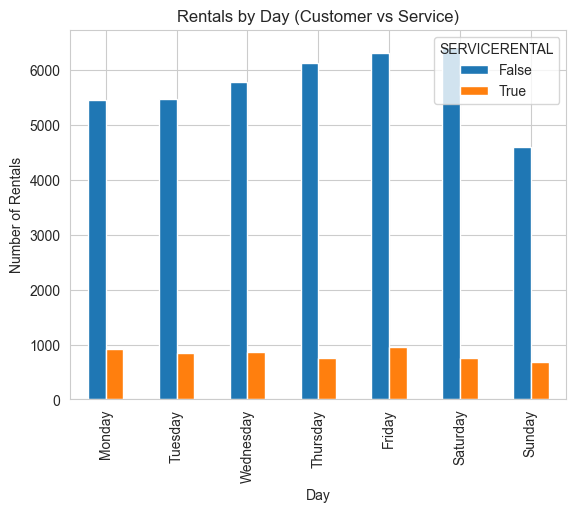

In [9]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

daily = data.groupby(['day','SERVICERENTAL']).size().unstack().reindex(order)

daily.plot(kind='bar')

plt.title("Rentals by Day (Customer vs Service)")
plt.xlabel("Day")
plt.ylabel("Number of Rentals")

plt.show()

Insight:

* Helps identify **high-demand days**.
* Separates **customer demand vs operational activity**.

#### 4.3 Monthly Rental Trends


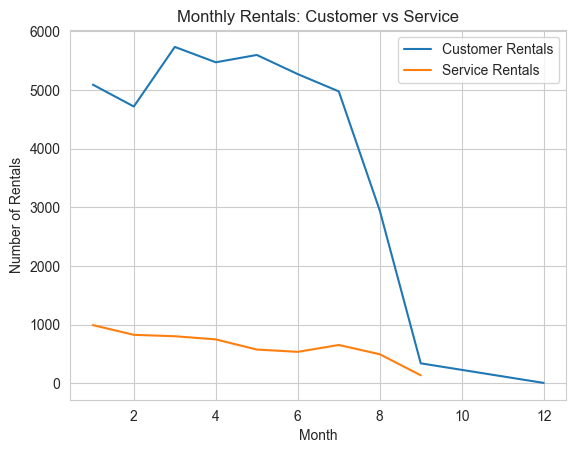

In [10]:
monthly = data.groupby(['month','SERVICERENTAL']).size().unstack()

monthly.plot(kind='line')

plt.title("Monthly Rentals: Customer vs Service")
plt.xlabel("Month")
plt.ylabel("Number of Rentals")
plt.legend(['Customer Rentals','Service Rentals'])

plt.show()

Insight:

* Identifies **seasonal rental patterns**.

### 5. Battery Behavior Analysis

This section examines **customer preferences regarding battery levels**.

#### 5.1 Battery Level Categories


In [11]:
bins = [0,20,40,60,80,100]
labels = ['0-20','20-40','40-60','60-80','80-100']

data['battery_range'] = pd.cut(data['CHARGELEVELSTART'], bins=bins, labels=labels)

#### 5.2 Customer Rentals by Battery Level

Only customer rentals are considered to avoid operational bias.

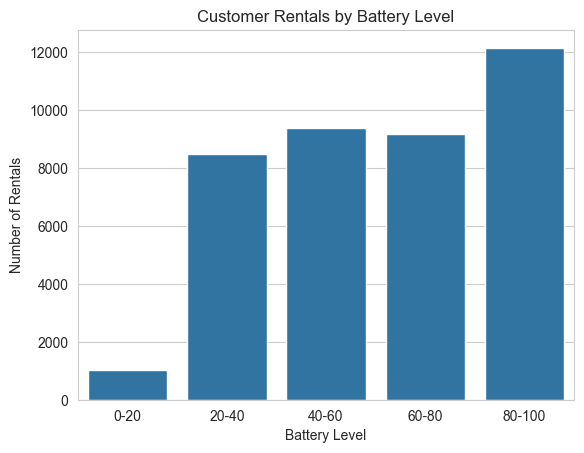

In [12]:
customer = data[data['SERVICERENTAL'] == False]

battery_counts = customer.groupby('battery_range').size()

sns.barplot(x=battery_counts.index, y=battery_counts.values)

plt.title("Customer Rentals by Battery Level")
plt.xlabel("Battery Level")
plt.ylabel("Number of Rentals")

plt.show()

Insight:

* Reveals **battery levels customers prefer when renting vehicles**.

### 6. Charging Behavior Analysis

This section evaluates **charging efficiency and interruptions**.

#### 6.1 Charging Interruptions

Charging interruptions occur when a vehicle is **plugged into a charger but does not reach 100% battery**, often because a customer rents the vehicle.


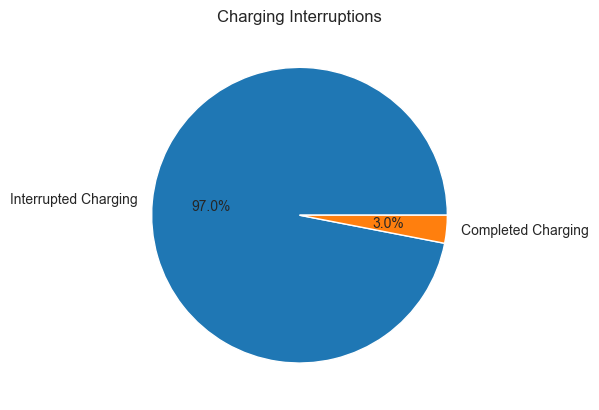

In [13]:
charging = data[data['CHARGED'] == True]

interruptions = charging[charging['CHARGELEVELEND'] < 100]

pie_data = [len(interruptions), len(charging) - len(interruptions)]
labels = ['Interrupted Charging','Completed Charging']
plt.pie(pie_data, labels=labels, autopct='%1.1f%%')
plt.title("Charging Interruptions")

plt.show()

Insight:

* Indicates **how often vehicles are rented while charging**


#### 6.2 Charging Events

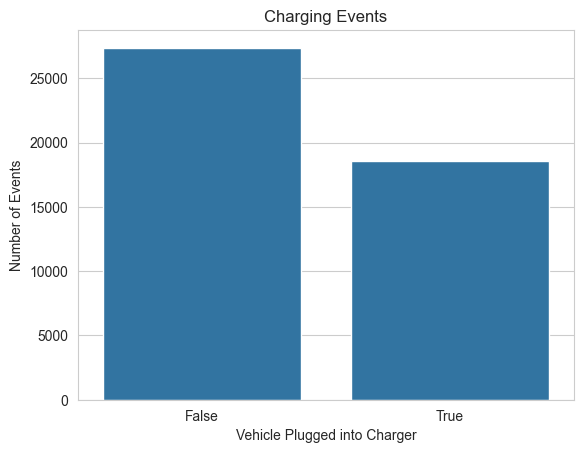

In [14]:
charging_counts = data['CHARGED'].value_counts()

sns.barplot(x=charging_counts.index.astype(str), y=charging_counts.values)

plt.title("Charging Events")
plt.xlabel("Vehicle Plugged into Charger")
plt.ylabel("Number of Events")

plt.show()

Insight:

* Shows how frequently vehicles **use charging stations**.

### 7. Charging Efficiency

#### 7.1 Vehicles Reaching Full Charge


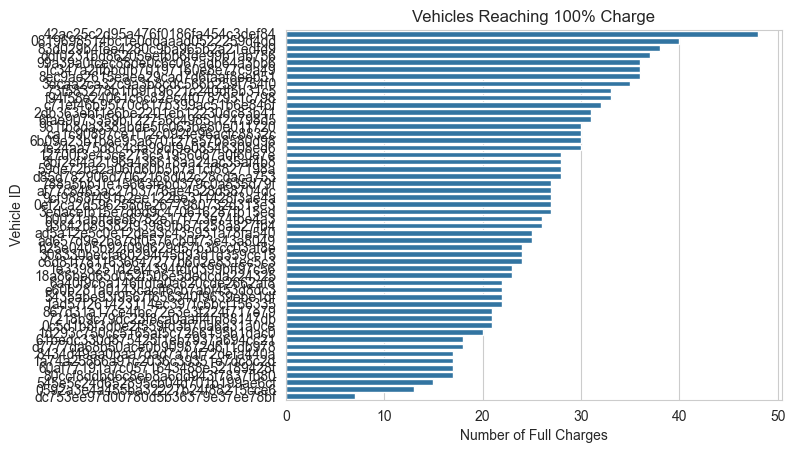

In [15]:
full_charge = data[data['CHARGELEVELEND'] == 100]

vehicle_counts = full_charge['VEHICLE_ID'].value_counts()

sns.barplot(x=vehicle_counts.values, y=vehicle_counts.index)

plt.title("Vehicles Reaching 100% Charge")
plt.xlabel("Number of Full Charges")
plt.ylabel("Vehicle ID")

plt.show()

Insight:

* Identifies vehicles that **occupy charging stations most frequently**.

#### 7.2 Service Agent Interventions

Service rentals indicate **operational actions such as vehicle relocation or charging**.

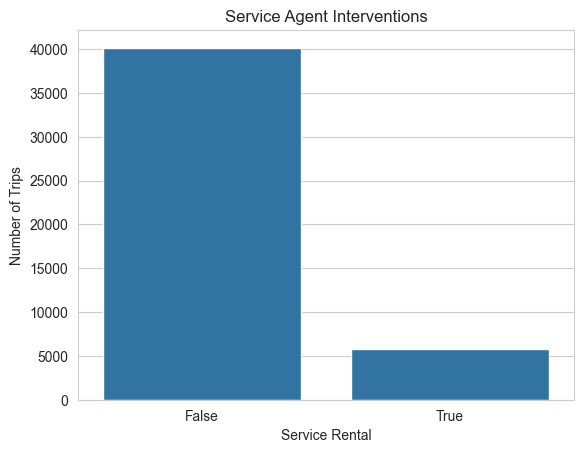

In [16]:
service_counts = data['SERVICERENTAL'].value_counts()

sns.barplot(x=service_counts.index.astype(str), y=service_counts.values)

plt.title("Service Agent Interventions")
plt.xlabel("Service Rental")
plt.ylabel("Number of Trips")

plt.show()

Insight:

* Shows **how often service agents interact with vehicles**.

## **Key Observations**

Based on the analysis:

* Rental demand varies across **days and months**.
* Customers tend to rent vehicles with **moderate battery levels**.
* Some vehicles are rented **before reaching full charge**, causing charging interruptions.
* Service agents frequently intervene to **manage fleet operations**.

These insights help determine **optimal charging management strategies**.